In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

# Load data

In [3]:
train = pd.read_csv("Titanic_train.csv")
test  = pd.read_csv("Titanic_test.csv")

In [4]:
print("Train shape:", train.shape)
print("Test  shape:", test.shape)

Train shape: (891, 12)
Test  shape: (418, 11)


In [5]:
train.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [6]:
test.head()

,PassengerId,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,892,3,"Kelly, Mr. James",male,34.5,0,0,330911,7.8292,NaN,Q
1,893,3,"Wilkes, Mrs. James (Ellen Needs)",female,47.0,1,0,363272,7.0000,NaN,S
2,894,2,"Myles, Mr. Thomas Francis",male,62.0,0,0,240276,9.6875,NaN,Q
3,895,3,"Wirz, Mr. Albert",male,27.0,0,0,315154,8.6625,NaN,S
4,896,3,"Hirvonen, Mrs. Alexander (Helga E Lindqvist)",female,22.0,1,1,3101298,12.2875,NaN,S


In [7]:
train.info()

<class 'pandas.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    str    
 4   Sex          891 non-null    str    
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    str    
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    str    
 11  Embarked     889 non-null    str    
dtypes: float64(2), int64(5), str(5)
memory usage: 118.9 KB


In [8]:
train.describe()

,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare
count,891.000000,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,446.000000,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,257.353842,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429
min,1.000000,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,223.500000,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,446.000000,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,668.500000,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,891.000000,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


# 2) Data cleaning

In [9]:
print("Missing values – Train:")
print(train.isnull().sum())
print()
print("Missing values – Test:")
print(test.isnull().sum())

Missing values – Train:
PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64

Missing values – Test:
PassengerId      0
Pclass           0
Name             0
Sex              0
Age             86
SibSp            0
Parch            0
Ticket           0
Fare             1
Cabin          327
Embarked         0
dtype: int64


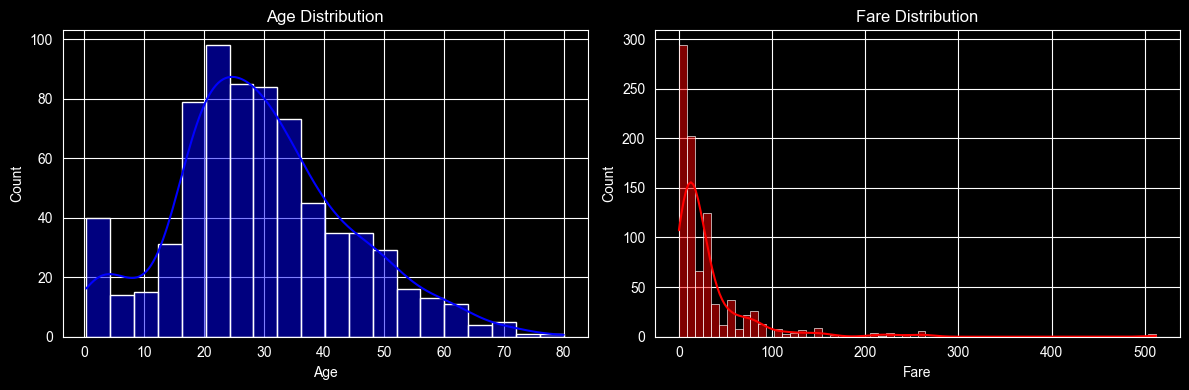

In [10]:
# Age & Fare distributions
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
sns.histplot(train['Age'].dropna(), kde=True, ax=axes[0], color='blue')
axes[0].set_title('Age Distribution')
sns.histplot(train['Fare'], kde=True, ax=axes[1], color='red')
axes[1].set_title('Fare Distribution')
plt.tight_layout()
plt.show()

In [11]:
train['Age']      = train['Age'].fillna(train['Age'].median())
test['Age']       = test['Age'].fillna(train['Age'].median())
test['Fare']      = test['Fare'].fillna(train['Fare'].median())
train['Embarked'] = train['Embarked'].fillna(train['Embarked'].mode()[0])
test['Embarked']  = test['Embarked'].fillna(train['Embarked'].mode()[0])

In [12]:
train.isnull().sum()

PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age              0
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         0
dtype: int64

In [13]:
test.isnull().sum()

PassengerId      0
Pclass           0
Name             0
Sex              0
Age              0
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          327
Embarked         0
dtype: int64

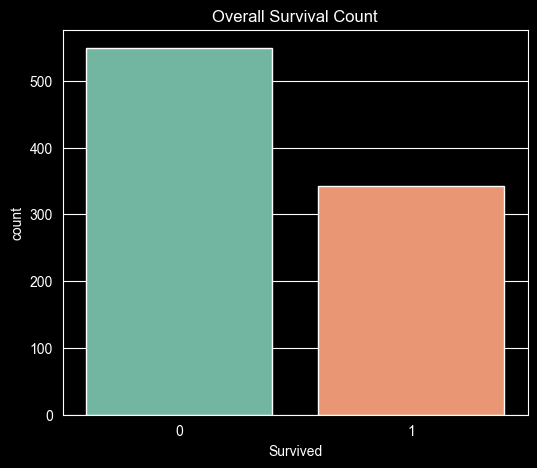

In [14]:
#data visualization
plt.figure(figsize=(6, 5))
#by data augumtantion
sns.countplot(data=train, x='Survived', hue='Survived', palette='Set2', legend=False)

plt.title('Overall Survival Count')
plt.show()

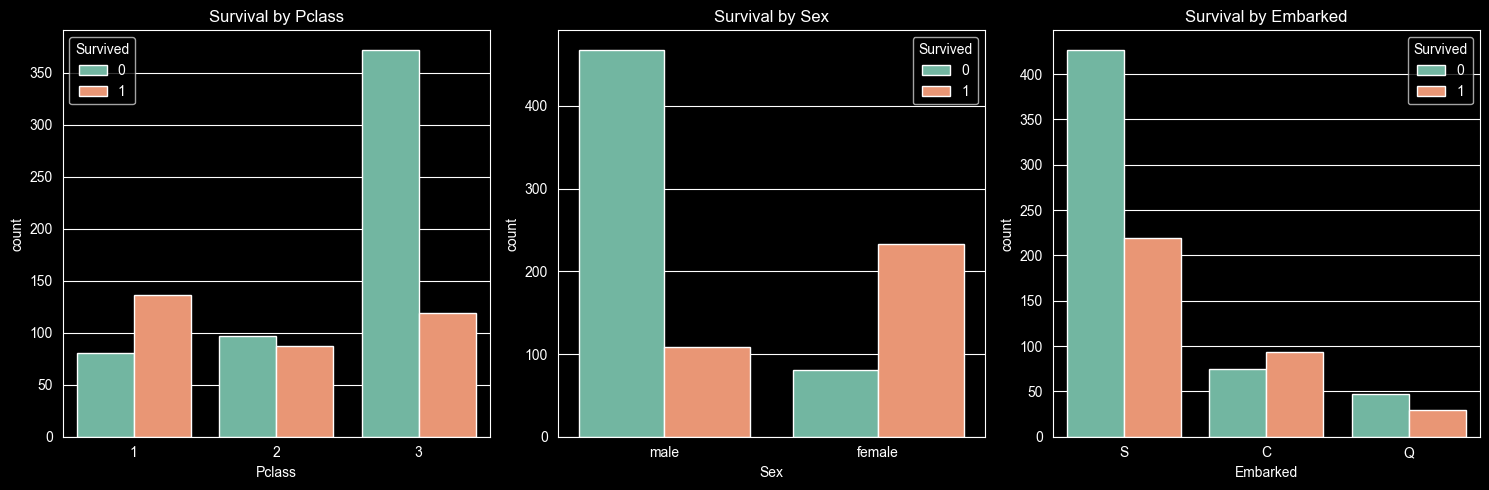

In [15]:

fig, axes = plt.subplots(1, 3, figsize=(15, 5))


sns.countplot(data=train, x='Pclass', hue='Survived', ax=axes[0], palette='Set2')
axes[0].set_title('Survival by Pclass')


sns.countplot(data=train, x='Sex', hue='Survived', ax=axes[1], palette='Set2')
axes[1].set_title('Survival by Sex')


sns.countplot(data=train, x='Embarked', hue='Survived', ax=axes[2], palette='Set2')
axes[2].set_title('Survival by Embarked')

plt.tight_layout()
plt.show()

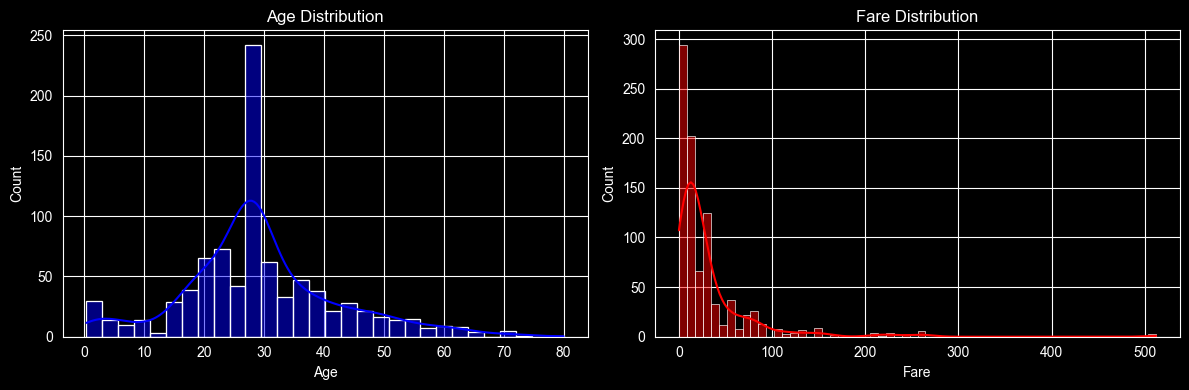

In [16]:
# Age & Fare distributions
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
sns.histplot(train['Age'].dropna(), kde=True, ax=axes[0], color='blue')
axes[0].set_title('Age Distribution')
sns.histplot(train['Fare'], kde=True, ax=axes[1], color='red')
axes[1].set_title('Fare Distribution')
plt.tight_layout()
plt.show()

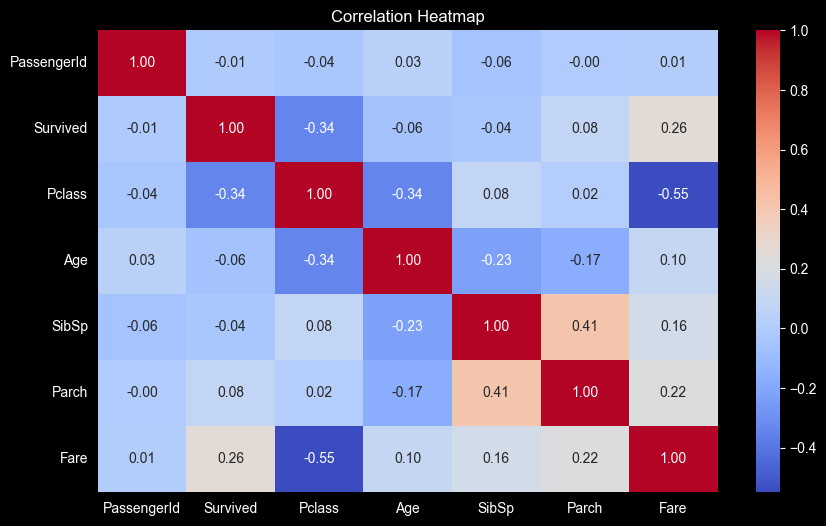

In [17]:
# Correlation heatmap (numeric only)
plt.figure(figsize=(10, 6))
numeric_train = train.select_dtypes(include=[np.number])
sns.heatmap(numeric_train.corr(), annot=True, fmt='.2f', cmap='coolwarm')
plt.title('Correlation Heatmap')
plt.show()

In [18]:
# Extract Title from Name
train['Title'] = train['Name'].str.extract(r',\s*([^\.]+)\.')
test['Title']  = test['Name'].str.extract(r',\s*([^\.]+)\.')
print(train['Title'].value_counts())

Title
Mr              517
Miss            182
Mrs             125
Master           40
Dr                7
Rev               6
Major             2
Mlle              2
Col               2
Don               1
Mme               1
Ms                1
Lady              1
Sir               1
Capt              1
the Countess      1
Jonkheer          1
Name: count, dtype: int64


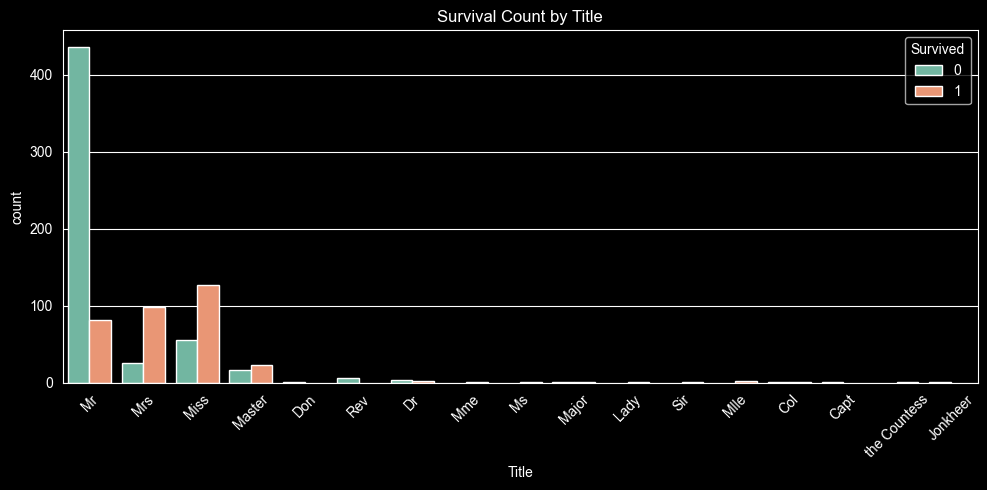

In [19]:
# Visualise survival by title
plt.figure(figsize=(10, 5))
sns.countplot(data=train, x='Title', hue='Survived', palette='Set2')
plt.title('Survival Count by Title')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

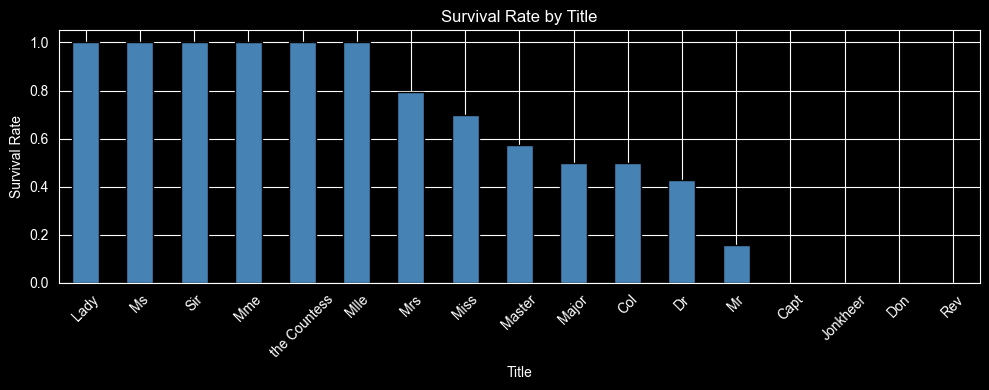

In [20]:
# Survival rate by title
survival_rate = train.groupby('Title')['Survived'].mean().sort_values(ascending=False)
survival_rate.plot(kind='bar', color='steelblue', edgecolor='black', figsize=(10, 4))
plt.title('Survival Rate by Title')
plt.ylabel('Survival Rate')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [21]:
# Consolidate rare titles
common_titles = ['Mr', 'Miss', 'Mrs', 'Master']
train['Title'] = train['Title'].apply(lambda x: x if x in common_titles else 'Rare')
test['Title']  = test['Title'].apply(lambda x: x if x in common_titles else 'Rare')
print(train['Title'].value_counts())

Title
Mr        517
Miss      182
Mrs       125
Master     40
Rare       27
Name: count, dtype: int64


In [22]:
# Family size & IsAlone
for df in [train, test]:
    df['FamilySize'] = df['SibSp'] + df['Parch'] + 1
    df['IsAlone'] = (df['FamilySize'] == 1).astype(int)

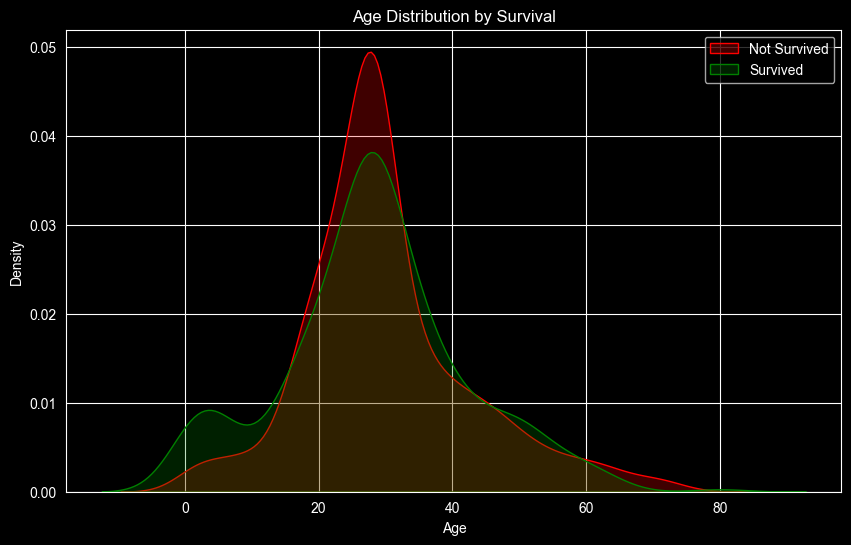

In [23]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10, 6))


sns.kdeplot(data=train[train['Survived'] == 0]['Age'], label='Not Survived', fill=True, color='red')
sns.kdeplot(data=train[train['Survived'] == 1]['Age'], label='Survived', fill=True, color='green')

plt.title('Age Distribution by Survival')
plt.xlabel('Age')
plt.ylabel('Density')
plt.legend()
plt.show()

In [24]:
# Age bins
for df in [train, test]:
    df['AgeBin'] = pd.cut(df['Age'], bins=[0, 12, 18, 35, 60, 100],
                          labels=['Child', 'Teen', 'Young', 'Adult', 'Senior'])

In [25]:
train.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked,Title,FamilySize,IsAlone,AgeBin
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S,Mr,2,0,Young
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C,Mrs,2,0,Adult
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S,Miss,1,1,Young
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S,Mrs,2,0,Young
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S,Mr,1,1,Young


In [26]:
train.isnull().sum()

PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age              0
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         0
Title            0
FamilySize       0
IsAlone          0
AgeBin           0
dtype: int64

In [27]:
test.isnull().sum()

PassengerId      0
Pclass           0
Name             0
Sex              0
Age              0
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          327
Embarked         0
Title            0
FamilySize       0
IsAlone          0
AgeBin           0
dtype: int64

In [28]:
# Drop columns not needed for modelling
drop_cols = ['PassengerId', 'Ticket', 'Cabin', 'Name', 'SibSp', 'Parch']
train.drop(columns=drop_cols, inplace=True)
test.drop(columns=drop_cols, inplace=True)

In [29]:
train.head()

,Survived,Pclass,Sex,Age,Fare,Embarked,Title,FamilySize,IsAlone,AgeBin
0,0,3,male,22.0,7.2500,S,Mr,2,0,Young
1,1,1,female,38.0,71.2833,C,Mrs,2,0,Adult
2,1,3,female,26.0,7.9250,S,Miss,1,1,Young
3,1,1,female,35.0,53.1000,S,Mrs,2,0,Young
4,0,3,male,35.0,8.0500,S,Mr,1,1,Young


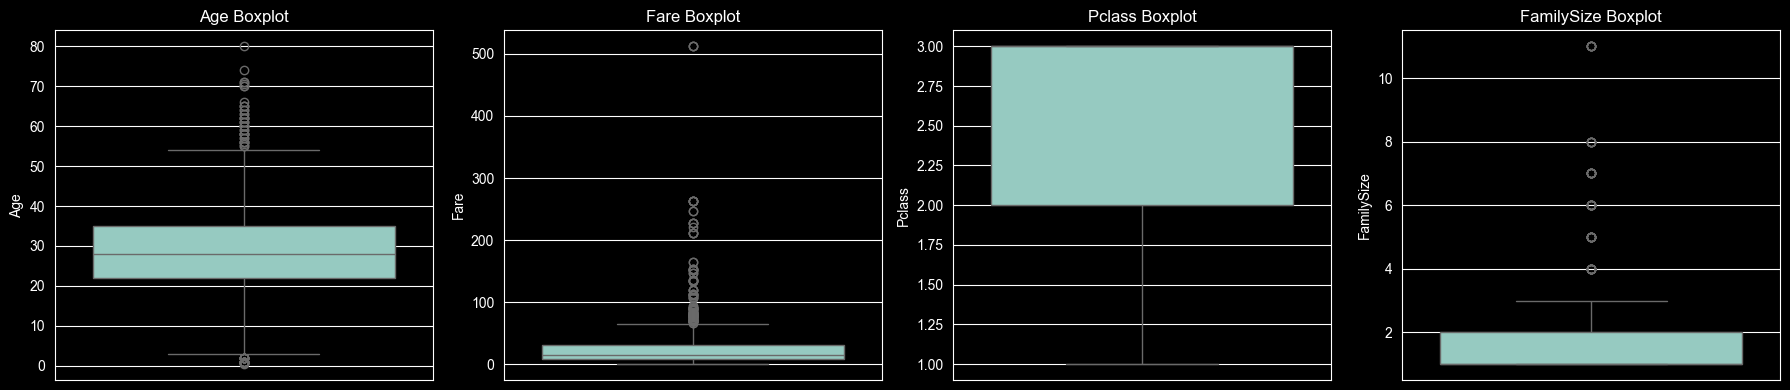

In [30]:

fig, axes = plt.subplots(1, 4, figsize=(18, 4))

for ax, col in zip(axes, ['Age', 'Fare', 'Pclass', 'FamilySize']):
    sns.boxplot(data=train, y=col, ax=ax)
    ax.set_title(f'{col} Boxplot')

plt.tight_layout()
plt.show()

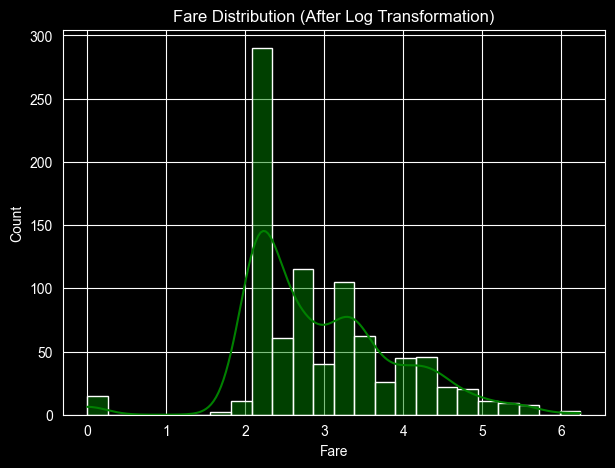

In [31]:

train['Fare'] = train['Fare'].apply(np.log1p)
test['Fare'] = test['Fare'].apply(np.log1p)


plt.figure(figsize=(7, 5))
sns.histplot(train['Fare'], kde=True, color='green')
plt.title('Fare Distribution (After Log Transformation)')
plt.show()

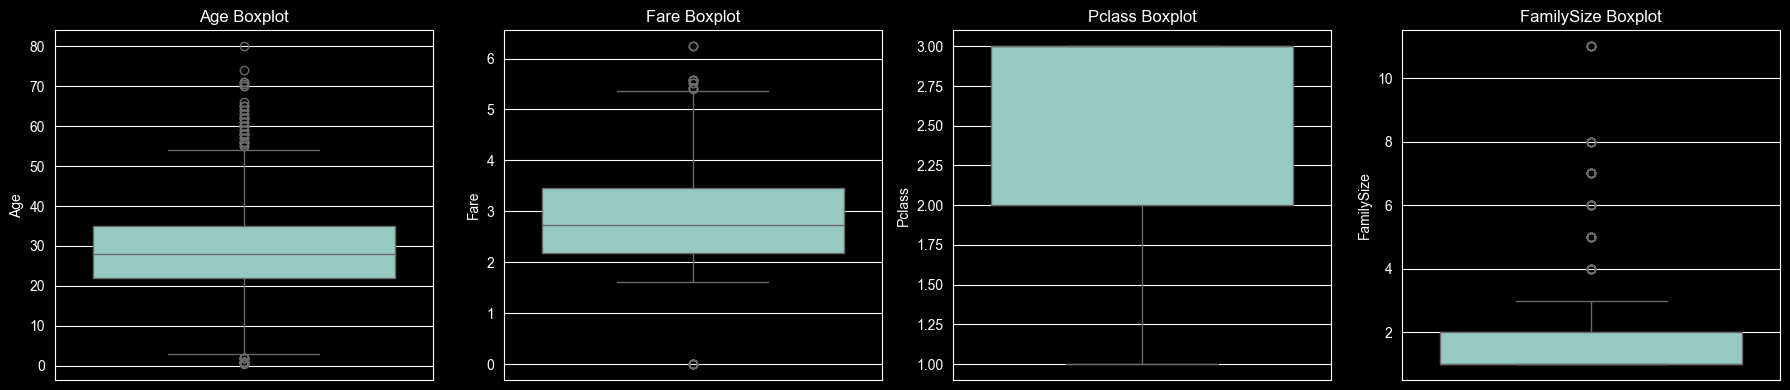

In [32]:
#the boxplots after log transformation
fig, axes = plt.subplots(1, 4, figsize=(18, 4))
for ax, col in zip(axes, ['Age', 'Fare', 'Pclass', 'FamilySize']):
    sns.boxplot(data=train, y=col, ax=ax)
    ax.set_title(f'{col} Boxplot')
    

plt.tight_layout()
plt.show()    

In [33]:
# Encode binary: Sex
train['Sex'] = train['Sex'].map({'male': 0, 'female': 1})
test['Sex']  = test['Sex'].map({'male': 0, 'female': 1})

In [34]:
train = pd.get_dummies(train, columns=['Embarked', 'Title'], drop_first=True)
test  = pd.get_dummies(test,  columns=['Embarked', 'Title'], drop_first=True)

In [35]:
train.head()

,Survived,Pclass,Sex,Age,Fare,FamilySize,IsAlone,AgeBin,Embarked_Q,Embarked_S,Title_Miss,Title_Mr,Title_Mrs,Title_Rare
0,0,3,0,22.0,2.110213,2,0,Young,False,True,False,True,False,False
1,1,1,1,38.0,4.280593,2,0,Adult,False,False,False,False,True,False
2,1,3,1,26.0,2.188856,1,1,Young,False,True,True,False,False,False
3,1,1,1,35.0,3.990834,2,0,Young,False,True,False,False,True,False
4,0,3,0,35.0,2.202765,1,1,Young,False,True,False,True,False,False


In [36]:
# One-hot encode AgeBin
train = pd.get_dummies(train, columns=['AgeBin'], drop_first=False, prefix='AgeBin')
test = pd.get_dummies(test, columns=['AgeBin'], drop_first=False, prefix='AgeBin')

# Ensure both datasets have the same columns
train_cols = set(train.columns)
test_cols = set(test.columns)

# Add missing columns to test with 0 values
for col in train_cols - test_cols:
    test[col] = 0

# Reorder test columns to match train
test = test[train.columns]

In [37]:
train.head()

,Survived,Pclass,Sex,Age,Fare,FamilySize,IsAlone,Embarked_Q,Embarked_S,Title_Miss,Title_Mr,Title_Mrs,Title_Rare,AgeBin_Child,AgeBin_Teen,AgeBin_Young,AgeBin_Adult,AgeBin_Senior
0,0,3,0,22.0,2.110213,2,0,False,True,False,True,False,False,False,False,True,False,False
1,1,1,1,38.0,4.280593,2,0,False,False,False,False,True,False,False,False,False,True,False
2,1,3,1,26.0,2.188856,1,1,False,True,True,False,False,False,False,False,True,False,False
3,1,1,1,35.0,3.990834,2,0,False,True,False,False,True,False,False,False,True,False,False
4,0,3,0,35.0,2.202765,1,1,False,True,False,True,False,False,False,False,True,False,False


In [38]:
for df in [train, test]:
    bool_cols = df.select_dtypes(include='bool').columns
    df[bool_cols] = df[bool_cols].astype(int)

print("Train columns:", train.columns.tolist())
print("Test columns:", test.columns.tolist())

Train columns: ['Survived', 'Pclass', 'Sex', 'Age', 'Fare', 'FamilySize', 'IsAlone', 'Embarked_Q', 'Embarked_S', 'Title_Miss', 'Title_Mr', 'Title_Mrs', 'Title_Rare', 'AgeBin_Child', 'AgeBin_Teen', 'AgeBin_Young', 'AgeBin_Adult', 'AgeBin_Senior']
Test columns: ['Survived', 'Pclass', 'Sex', 'Age', 'Fare', 'FamilySize', 'IsAlone', 'Embarked_Q', 'Embarked_S', 'Title_Miss', 'Title_Mr', 'Title_Mrs', 'Title_Rare', 'AgeBin_Child', 'AgeBin_Teen', 'AgeBin_Young', 'AgeBin_Adult', 'AgeBin_Senior']


In [39]:
train.head()

,Survived,Pclass,Sex,Age,Fare,FamilySize,IsAlone,Embarked_Q,Embarked_S,Title_Miss,Title_Mr,Title_Mrs,Title_Rare,AgeBin_Child,AgeBin_Teen,AgeBin_Young,AgeBin_Adult,AgeBin_Senior
0,0,3,0,22.0,2.110213,2,0,0,1,0,1,0,0,0,0,1,0,0
1,1,1,1,38.0,4.280593,2,0,0,0,0,0,1,0,0,0,0,1,0
2,1,3,1,26.0,2.188856,1,1,0,1,1,0,0,0,0,0,1,0,0
3,1,1,1,35.0,3.990834,2,0,0,1,0,0,1,0,0,0,1,0,0
4,0,3,0,35.0,2.202765,1,1,0,1,0,1,0,0,0,0,1,0,0


In [40]:
# Standard scaling
# min-max scaling can be used for tree-based models the mae the accuracy deacrese
# Note: AgeBin is now one-hot encoded, so we only scale continuous numeric columns

scaler = StandardScaler()
cols_to_scale = ['Age', 'Fare', 'Pclass', 'FamilySize']
train[cols_to_scale] = scaler.fit_transform(train[cols_to_scale])
test[cols_to_scale]  = scaler.transform(test[cols_to_scale])
train.head()

,Survived,Pclass,Sex,Age,Fare,FamilySize,IsAlone,Embarked_Q,Embarked_S,Title_Miss,Title_Mr,Title_Mrs,Title_Rare,AgeBin_Child,AgeBin_Teen,AgeBin_Young,AgeBin_Adult,AgeBin_Senior
0,0,0.827377,0,-0.565736,-0.879741,0.059160,0,0,1,0,1,0,0,0,0,1,0,0
1,1,-1.566107,1,0.663861,1.361220,0.059160,0,0,0,0,0,1,0,0,0,0,1,0
2,1,0.827377,1,-0.258337,-0.798540,-0.560975,1,0,1,1,0,0,0,0,0,1,0,0
3,1,-1.566107,1,0.433312,1.062038,0.059160,0,0,1,0,0,1,0,0,0,1,0,0
4,0,0.827377,0,0.433312,-0.784179,-0.560975,1,0,1,0,1,0,0,0,0,1,0,0


In [41]:
X = train.drop('Survived', axis=1)
y = train['Survived']
# 75% 25%
# 60% 40%
# 90% 10%
X_train, X_val, y_train, y_val = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y)

test = test[X_train.columns]

print("X_train:", X_train.shape)
print("X_val:  ", X_val.shape)



X_train: (712, 17)
X_val:   (179, 17)


In [42]:
# Drop Age first
train.drop('Age', axis=1, inplace=True)
test.drop('Age', axis=1, inplace=True)

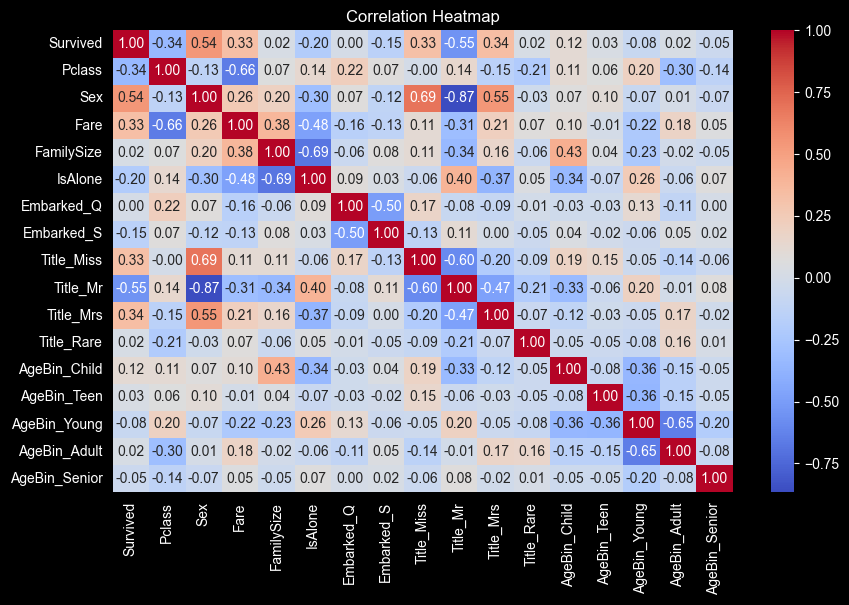

In [43]:
# Correlation heatmap (numeric only)
plt.figure(figsize=(10, 6))
numeric_train = train.select_dtypes(include=[np.number])
sns.heatmap(numeric_train.corr(), annot=True, fmt='.2f', cmap='coolwarm')
plt.title('Correlation Heatmap')
plt.show()

In [44]:
train.head()

,Survived,Pclass,Sex,Fare,FamilySize,IsAlone,Embarked_Q,Embarked_S,Title_Miss,Title_Mr,Title_Mrs,Title_Rare,AgeBin_Child,AgeBin_Teen,AgeBin_Young,AgeBin_Adult,AgeBin_Senior
0,0,0.827377,0,-0.879741,0.059160,0,0,1,0,1,0,0,0,0,1,0,0
1,1,-1.566107,1,1.361220,0.059160,0,0,0,0,0,1,0,0,0,0,1,0
2,1,0.827377,1,-0.798540,-0.560975,1,0,1,1,0,0,0,0,0,1,0,0
3,1,-1.566107,1,1.062038,0.059160,0,0,1,0,0,1,0,0,0,1,0,0
4,0,0.827377,0,-0.784179,-0.560975,1,0,1,0,1,0,0,0,0,1,0,0


In [45]:
lr = LogisticRegression(random_state=42, max_iter=1000)
lr.fit(X_train, y_train)

lr_train_acc = accuracy_score(y_train, lr.predict(X_train))
lr_val_acc   = accuracy_score(y_val,   lr.predict(X_val))

print("=" * 50)
print("Model : Logistic Regression")
print(f"Train Accuracy : {lr_train_acc:.4f}")
print(f"Val   Accuracy : {lr_val_acc:.4f}")
print(classification_report(y_val, lr.predict(X_val)))

Model : Logistic Regression
Train Accuracy : 0.8244
Val   Accuracy : 0.8380
              precision    recall  f1-score   support

           0       0.85      0.90      0.87       110
           1       0.82      0.74      0.78        69

    accuracy                           0.84       179
   macro avg       0.83      0.82      0.83       179
weighted avg       0.84      0.84      0.84       179



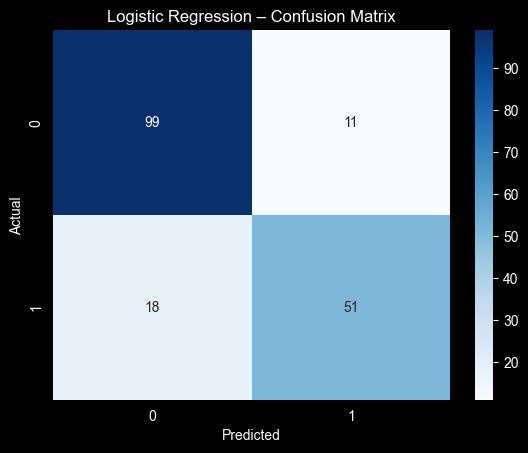

In [46]:
cm = confusion_matrix(y_val, lr.predict(X_val))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title('Logistic Regression – Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

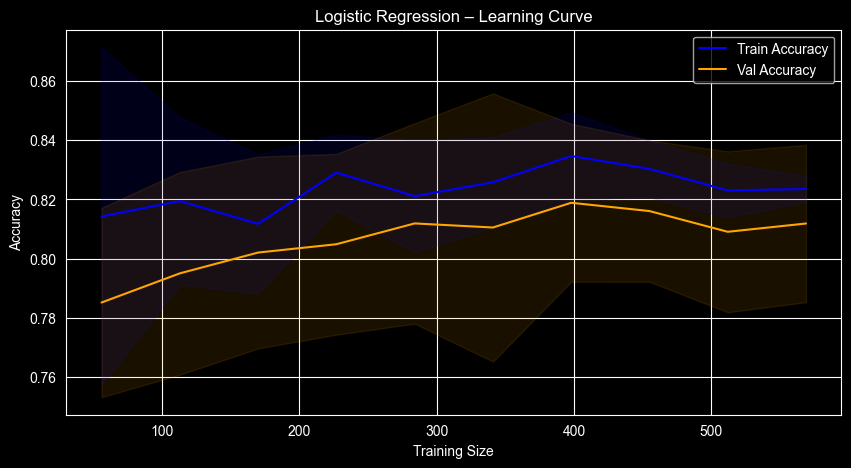

In [47]:
from sklearn.model_selection import learning_curve

train_sizes, train_scores, val_scores = learning_curve(
    lr, X_train, y_train, cv=5, scoring='accuracy',
    train_sizes=np.linspace(0.1, 1.0, 10))

plt.figure(figsize=(10, 5))
plt.plot(train_sizes, train_scores.mean(axis=1), label='Train Accuracy', color='blue')
plt.plot(train_sizes, val_scores.mean(axis=1),   label='Val Accuracy',   color='orange')
plt.fill_between(train_sizes,
                 train_scores.mean(axis=1) - train_scores.std(axis=1),
                 train_scores.mean(axis=1) + train_scores.std(axis=1), alpha=0.1, color='blue')
plt.fill_between(train_sizes,
                 val_scores.mean(axis=1) - val_scores.std(axis=1),
                 val_scores.mean(axis=1) + val_scores.std(axis=1), alpha=0.1, color='orange')
plt.title('Logistic Regression – Learning Curve')
plt.xlabel('Training Size')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True)
plt.show()

In [48]:
svm = SVC(random_state=42)
svm.fit(X_train, y_train)

svm_train_acc = accuracy_score(y_train, svm.predict(X_train))
svm_val_acc   = accuracy_score(y_val,   svm.predict(X_val))

print("=" * 50)
print("Model : SVM")
print(f"Train Accuracy : {svm_train_acc:.4f}")
print(f"Val   Accuracy : {svm_val_acc:.4f}")
print(classification_report(y_val, svm.predict(X_val)))

Model : SVM
Train Accuracy : 0.8455
Val   Accuracy : 0.8324
              precision    recall  f1-score   support

           0       0.83      0.91      0.87       110
           1       0.83      0.71      0.77        69

    accuracy                           0.83       179
   macro avg       0.83      0.81      0.82       179
weighted avg       0.83      0.83      0.83       179



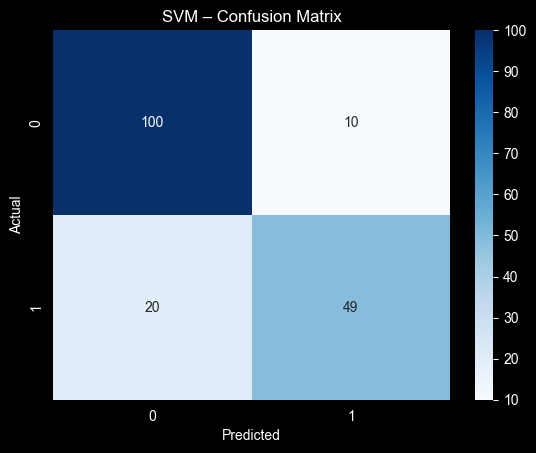

In [49]:
cm = confusion_matrix(y_val, svm.predict(X_val))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title('SVM – Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

In [50]:
# ── Decision Tree ────────────────────────────────────────────────────────────
dt = DecisionTreeClassifier(random_state=42, max_depth=5)
dt.fit(X_train, y_train)

dt_train_acc = accuracy_score(y_train, dt.predict(X_train))
dt_val_acc   = accuracy_score(y_val,   dt.predict(X_val))

print("=" * 50)
print("Model : Decision Tree")
print(f"Train Accuracy : {dt_train_acc:.4f}")
print(f"Val   Accuracy : {dt_val_acc:.4f}")
print(classification_report(y_val, dt.predict(X_val)))



Model : Decision Tree
Train Accuracy : 0.8708
Val   Accuracy : 0.8268
              precision    recall  f1-score   support

           0       0.86      0.86      0.86       110
           1       0.78      0.77      0.77        69

    accuracy                           0.83       179
   macro avg       0.82      0.82      0.82       179
weighted avg       0.83      0.83      0.83       179



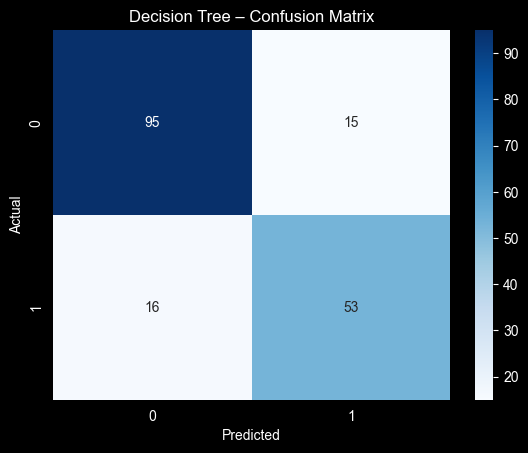

In [51]:
cm = confusion_matrix(y_val, dt.predict(X_val))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title('Decision Tree – Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

In [52]:
rf = RandomForestClassifier(random_state=42,max_depth=5)
rf.fit(X_train, y_train)

rf_train_acc = accuracy_score(y_train, rf.predict(X_train))
rf_val_acc   = accuracy_score(y_val,   rf.predict(X_val))

print("=" * 50)
print("Model : Random Forest")
print(f"Train Accuracy : {rf_train_acc:.4f}")
print(f"Val   Accuracy : {rf_val_acc:.4f}")
print(classification_report(y_val, rf.predict(X_val)))

Model : Random Forest
Train Accuracy : 0.8483
Val   Accuracy : 0.8156
              precision    recall  f1-score   support

           0       0.82      0.89      0.86       110
           1       0.80      0.70      0.74        69

    accuracy                           0.82       179
   macro avg       0.81      0.79      0.80       179
weighted avg       0.81      0.82      0.81       179



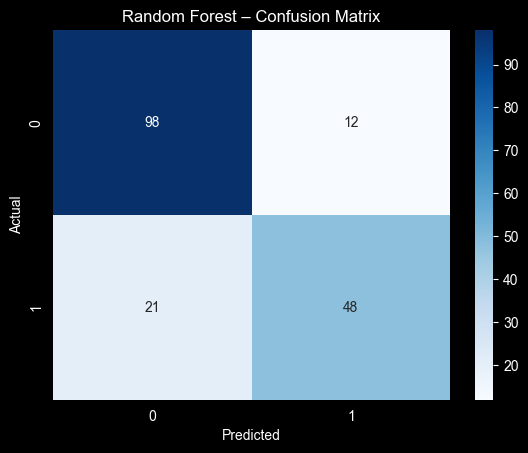

In [53]:
cm = confusion_matrix(y_val, rf.predict(X_val))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title('Random Forest – Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

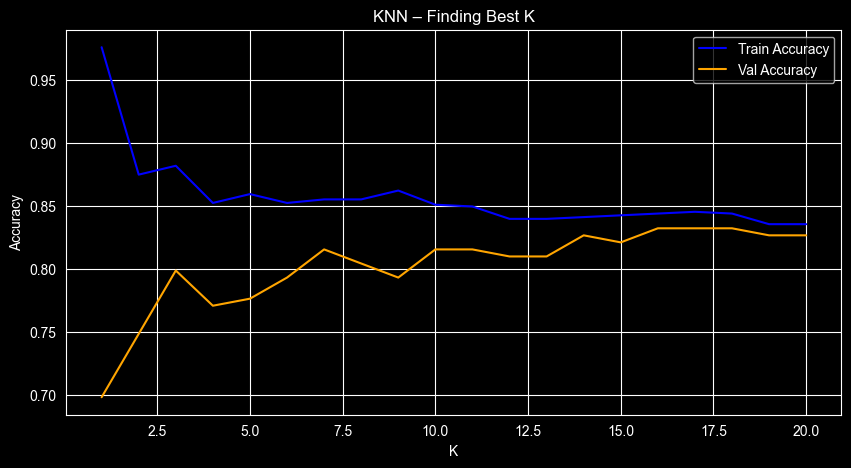

Best K: 16 → Val Accuracy: 0.8324
Model : KNN
Train Accuracy : 0.8441
Val   Accuracy : 0.8324
              precision    recall  f1-score   support

           0       0.83      0.92      0.87       110
           1       0.84      0.70      0.76        69

    accuracy                           0.83       179
   macro avg       0.83      0.81      0.82       179
weighted avg       0.83      0.83      0.83       179



In [54]:
# Find best K
k_range = range(1, 21)
train_scores = []
val_scores = []

for k in k_range:
    knn = KNeighborsClassifier(n_neighbors=k)
    knn.fit(X_train, y_train)
    train_scores.append(accuracy_score(y_train, knn.predict(X_train)))
    val_scores.append(accuracy_score(y_val, knn.predict(X_val)))

# Plot
plt.figure(figsize=(10, 5))
plt.plot(k_range, train_scores, label='Train Accuracy', color='blue')
plt.plot(k_range, val_scores,   label='Val Accuracy',   color='orange')
plt.title('KNN – Finding Best K')
plt.xlabel('K')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True)
plt.show()

best_k = val_scores.index(max(val_scores)) + 1
print(f"Best K: {best_k} → Val Accuracy: {max(val_scores):.4f}")

# Train with best K
knn = KNeighborsClassifier(n_neighbors=best_k)
knn.fit(X_train, y_train)

knn_train_acc = accuracy_score(y_train, knn.predict(X_train))
knn_val_acc   = accuracy_score(y_val,   knn.predict(X_val))

print("=" * 50)
print("Model : KNN")
print(f"Train Accuracy : {knn_train_acc:.4f}")
print(f"Val   Accuracy : {knn_val_acc:.4f}")
print(classification_report(y_val, knn.predict(X_val)))

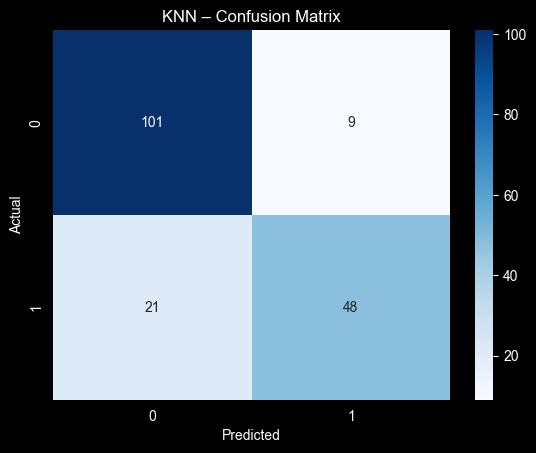

In [55]:
cm = confusion_matrix(y_val, knn.predict(X_val))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title('KNN – Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()


In [56]:
# ── Logistic Regression Tuning ───────────────────────────────────────────────
lr_params = {
    'C': [0.01, 0.1, 1, 10, 100],
    'penalty': ['l1', 'l2'],
    'solver': ['liblinear']
}
lr_grid = GridSearchCV(LogisticRegression(random_state=42, max_iter=10), param_grid=
                       lr_params, cv=5, scoring='accuracy', n_jobs=-1)
lr_grid.fit(X_train, y_train)
print("Best LR params:", lr_grid.best_params_)
print("Best CV score :", round(lr_grid.best_score_, 4))

lr_best = lr_grid.best_estimator_
lr_best_train_acc = accuracy_score(y_train, lr_best.predict(X_train))
lr_best_val_acc   = accuracy_score(y_val,   lr_best.predict(X_val))

print("=" * 50)
print("Model : Logistic Regression (Tuned)")
print(f"Train Accuracy : {lr_best_train_acc:.4f}")
print(f"Val   Accuracy : {lr_best_val_acc:.4f}")
print(f"Gap (Overfitting): {lr_best_train_acc - lr_best_val_acc:.4f}")
print(classification_report(y_val, lr_best.predict(X_val)))

Best LR params: {'C': 100, 'penalty': 'l2', 'solver': 'liblinear'}
Best CV score : 0.8203
Model : Logistic Regression (Tuned)
Train Accuracy : 0.8244
Val   Accuracy : 0.8492
Gap (Overfitting): -0.0247
              precision    recall  f1-score   support

           0       0.85      0.91      0.88       110
           1       0.84      0.75      0.79        69

    accuracy                           0.85       179
   macro avg       0.85      0.83      0.84       179
weighted avg       0.85      0.85      0.85       179



C:\Users\ATG\PycharmProjects\PythonProject5\.venv\Lib\site-packages\sklearn\linear_model\_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(


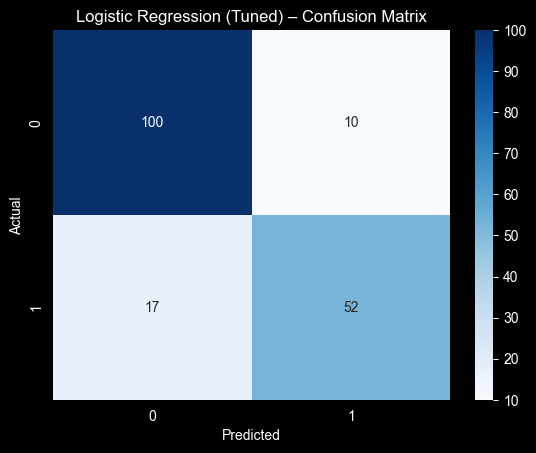

In [57]:
cm = confusion_matrix(y_val, lr_best.predict(X_val))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title('Logistic Regression (Tuned) – Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

In [58]:
# ── SVM Tuning ───────────────────────────────────────────────────────────────
svm_params = {
    'C': [0.1, 1, 10],
    #guessing that gamma is more relevant for RBF kernel, but we can still include it for linear to see if it has any effect (it should be ignored by the linear kernel).
    'kernel': ['rbf', 'linear'],
    'gamma': ['scale', 'auto']
}
svm_grid = GridSearchCV(SVC(random_state=42),
                        svm_params, cv=5, scoring='accuracy', n_jobs=-1)
svm_grid.fit(X_train, y_train)
print("Best SVM params:", svm_grid.best_params_)
print("Best CV score  :", round(svm_grid.best_score_, 4))

svm_best = svm_grid.best_estimator_
svm_best_train_acc = accuracy_score(y_train, svm_best.predict(X_train))
svm_best_val_acc   = accuracy_score(y_val,   svm_best.predict(X_val))

print("=" * 50)
print("Model : SVM (Tuned)")
print(f"Train Accuracy : {svm_best_train_acc:.4f}")
print(f"Val   Accuracy : {svm_best_val_acc:.4f}")
print(f"Gap (Overfitting): {svm_best_train_acc - svm_best_val_acc:.4f}")
print(classification_report(y_val, svm_best.predict(X_val)))



Best SVM params: {'C': 10, 'gamma': 'scale', 'kernel': 'linear'}
Best CV score  : 0.8273
Model : SVM (Tuned)
Train Accuracy : 0.8272
Val   Accuracy : 0.8268
Gap (Overfitting): 0.0004
              precision    recall  f1-score   support

           0       0.83      0.90      0.86       110
           1       0.82      0.71      0.76        69

    accuracy                           0.83       179
   macro avg       0.82      0.81      0.81       179
weighted avg       0.83      0.83      0.82       179



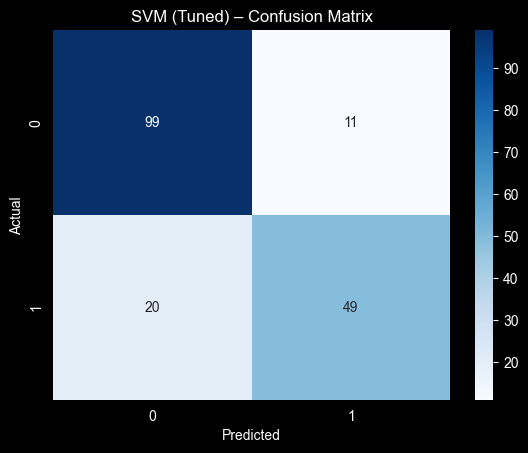

In [59]:
cm = confusion_matrix(y_val, svm_best.predict(X_val))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title('SVM (Tuned) – Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

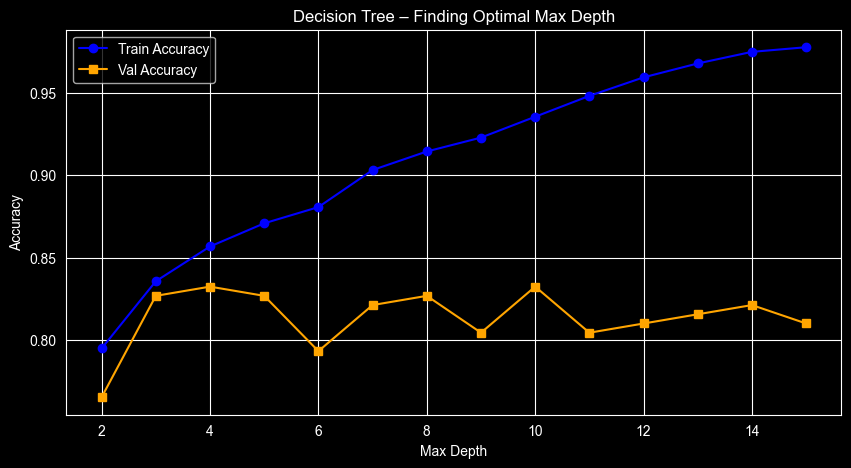

Optimal Max Depth: 4
Model : Decision Tree (Tuned)
Train Accuracy : 0.8567
Val   Accuracy : 0.8324
Gap (Overfitting): 0.0243
              precision    recall  f1-score   support

           0       0.85      0.88      0.87       110
           1       0.80      0.75      0.78        69

    accuracy                           0.83       179
   macro avg       0.83      0.82      0.82       179
weighted avg       0.83      0.83      0.83       179



In [60]:
# ── Decision Tree Tuning ──────────────────────────────────────────────────────
# Test different max_depth values to find the optimal balance
depth_range = range(2, 16)
#over 16 caouse overfitting, so i stopped at 16
dt_train_scores = []
dt_val_scores = []

for depth in depth_range:
    dt_temp = DecisionTreeClassifier(random_state=42, max_depth=depth)
    dt_temp.fit(X_train, y_train)
    dt_train_scores.append(accuracy_score(y_train, dt_temp.predict(X_train)))
    dt_val_scores.append(accuracy_score(y_val, dt_temp.predict(X_val)))

# Plot to find optimal depth

plt.figure(figsize=(10, 5))
plt.plot(depth_range, dt_train_scores, label='Train Accuracy', color='blue', marker='o')
plt.plot(depth_range, dt_val_scores,   label='Val Accuracy',   color='orange', marker='s')
plt.title('Decision Tree – Finding Optimal Max Depth')
plt.xlabel('Max Depth')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True)
plt.show()

# Find the optimal depth
optimal_depth = depth_range[dt_val_scores.index(max(dt_val_scores))]
print(f"Optimal Max Depth: {optimal_depth}")

# Train the final model with the optimal depth
dt_best = DecisionTreeClassifier(random_state=42, max_depth=4)
dt_best.fit(X_train, y_train)

dt_best_train_acc = accuracy_score(y_train, dt_best.predict(X_train))
dt_best_val_acc   = accuracy_score(y_val,   dt_best.predict(X_val))

print("=" * 50)
print("Model : Decision Tree (Tuned)")
print(f"Train Accuracy : {dt_best_train_acc:.4f}")
print(f"Val   Accuracy : {dt_best_val_acc:.4f}")
print(f"Gap (Overfitting): {dt_best_train_acc - dt_best_val_acc:.4f}")
print(classification_report(y_val, dt_best.predict(X_val)))

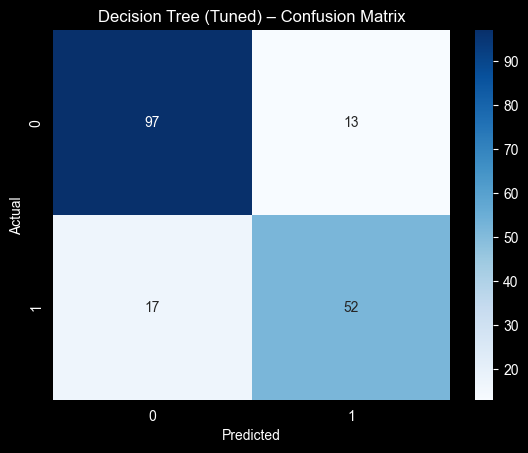

In [61]:
cm = confusion_matrix(y_val, dt_best.predict(X_val))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title('Decision Tree (Tuned) – Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

                      Model  Train Accuracy  Val Accuracy
Logistic Regression (Tuned)        0.824438      0.849162
        Logistic Regression        0.824438      0.837989
                        SVM        0.845506      0.832402
      Decision Tree (Tuned)        0.856742      0.832402
                        KNN        0.844101      0.832402
                SVM (Tuned)        0.827247      0.826816
              Decision Tree        0.870787      0.826816
              Random Forest        0.848315      0.815642


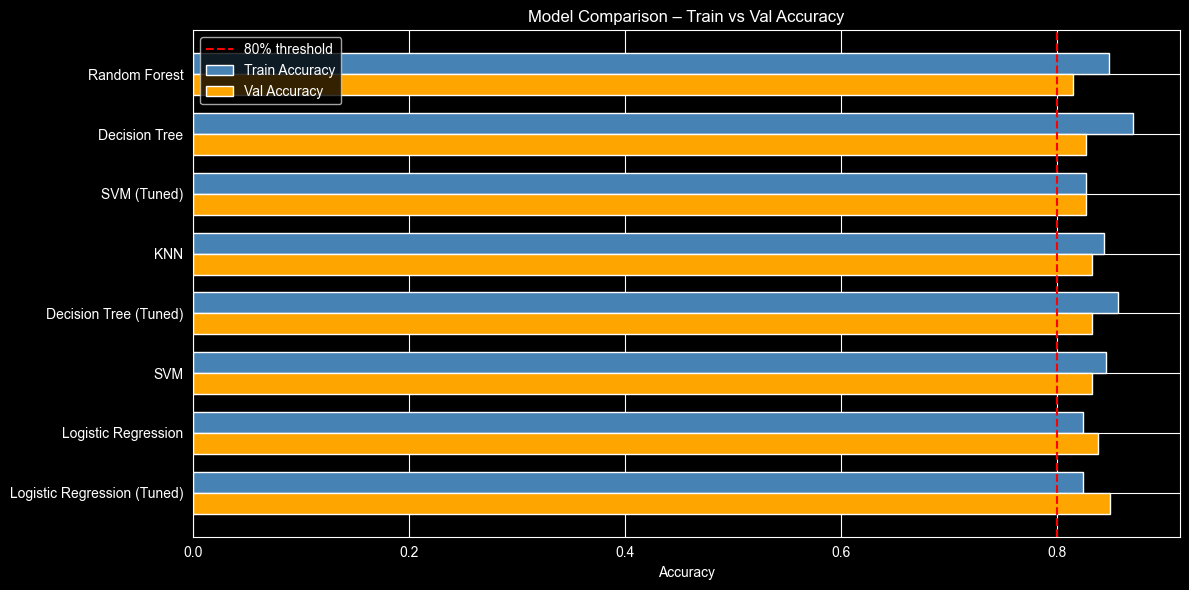

In [62]:
# ── Model Comparison ──────────────────────────────────────────────────────────
results = pd.DataFrame({
    # xgboost can be added here as well if we have time to train it, but it might take a bit longer to run compared to the other models.
    # catboost can also be added, but it might require additional installation and setup, so we can consider it if we have time after covering the main models. 
    'Model': [
        'Logistic Regression',
        'Logistic Regression (Tuned)',
        'SVM',
        'SVM (Tuned)',
        'Decision Tree',
        'Decision Tree (Tuned)',
        'Random Forest',
        'KNN'
    ],
    'Train Accuracy': [
        lr_train_acc,
        lr_best_train_acc,
        svm_train_acc,
        svm_best_train_acc,
        dt_train_acc,
        dt_best_train_acc,
        rf_train_acc,
        knn_train_acc
    ],
    'Val Accuracy': [
        lr_val_acc,
        lr_best_val_acc,
        svm_val_acc,
        svm_best_val_acc,
        dt_val_acc,
        dt_best_val_acc,
        rf_val_acc,
        knn_val_acc
    ]
}).sort_values('Val Accuracy', ascending=False).reset_index(drop=True)

print(results.to_string(index=False))

# Graph
fig, ax = plt.subplots(figsize=(12, 6))
x = range(len(results))
width = 0.35

bars1 = ax.barh([i + width/2 for i in x], results['Train Accuracy'], width, label='Train Accuracy', color='steelblue')
bars2 = ax.barh([i - width/2 for i in x], results['Val Accuracy'],   width, label='Val Accuracy',   color='orange')

ax.axvline(x=0.80, color='red', linestyle='--', label='80% threshold')
ax.set_yticks(list(x))
ax.set_yticklabels(results['Model'])
ax.set_xlabel('Accuracy')
ax.set_title('Model Comparison – Train vs Val Accuracy')
ax.legend()
plt.tight_layout()
plt.show()

In [63]:
# ── Auto-select Best Model ─────────────────────────────────────────────────────
models_dict = {
    'Logistic Regression':        lr,
    'Logistic Regression (Tuned)': lr_best,
    'SVM':                        svm,
    'SVM (Tuned)':                svm_best,
    'Decision Tree':              dt,
    'Decision Tree (Tuned)':      dt_best,
    'Random Forest':              rf,
    'KNN':                        knn
}

val_accs = {
    'Logistic Regression':        lr_val_acc,
    'Logistic Regression (Tuned)': lr_best_val_acc,
    'SVM':                        svm_val_acc,
    'SVM (Tuned)':                svm_best_val_acc,
    'Decision Tree':              dt_val_acc,
    'Decision Tree (Tuned)':      dt_best_val_acc,
    'Random Forest':              rf_val_acc,
    'KNN':                        knn_val_acc
}

best_name  = max(val_accs, key=val_accs.get)
best_model = models_dict[best_name]
print(f"\n Best Model: {best_name} ({round(val_accs[best_name], 4)})")


 Best Model: Logistic Regression (Tuned) (0.8492)


In [64]:
print("X_train columns:", X_train.columns.tolist())
print("test columns:", test.columns.tolist())

X_train columns: ['Pclass', 'Sex', 'Age', 'Fare', 'FamilySize', 'IsAlone', 'Embarked_Q', 'Embarked_S', 'Title_Miss', 'Title_Mr', 'Title_Mrs', 'Title_Rare', 'AgeBin_Child', 'AgeBin_Teen', 'AgeBin_Young', 'AgeBin_Adult', 'AgeBin_Senior']
test columns: ['Pclass', 'Sex', 'Fare', 'FamilySize', 'IsAlone', 'Embarked_Q', 'Embarked_S', 'Title_Miss', 'Title_Mr', 'Title_Mrs', 'Title_Rare', 'AgeBin_Child', 'AgeBin_Teen', 'AgeBin_Young', 'AgeBin_Adult', 'AgeBin_Senior']


In [65]:
print("X_train columns:", X_train.columns.tolist())
print("test columns:", test.columns.tolist())
print("Missing:", set(X_train.columns) - set(test.columns))

X_train columns: ['Pclass', 'Sex', 'Age', 'Fare', 'FamilySize', 'IsAlone', 'Embarked_Q', 'Embarked_S', 'Title_Miss', 'Title_Mr', 'Title_Mrs', 'Title_Rare', 'AgeBin_Child', 'AgeBin_Teen', 'AgeBin_Young', 'AgeBin_Adult', 'AgeBin_Senior']
test columns: ['Pclass', 'Sex', 'Fare', 'FamilySize', 'IsAlone', 'Embarked_Q', 'Embarked_S', 'Title_Miss', 'Title_Mr', 'Title_Mrs', 'Title_Rare', 'AgeBin_Child', 'AgeBin_Teen', 'AgeBin_Young', 'AgeBin_Adult', 'AgeBin_Senior']
Missing: {'Age'}


In [66]:
# Ensure test has the same columns as X_train
test = test[X_train.columns]

test_preds = best_model.predict(test)
print("Prediction distribution:", pd.Series(test_preds).value_counts().to_dict())

submission = pd.DataFrame({'Prediction': test_preds})
submission.to_csv('titanic_predictions.csv', index=False)
print("Saved titanic_predictions.csv ")
submission.head(10)

KeyError: "['Age'] not in index"

In [ ]:
result_df = test.copy()
result_df['Prediction'] = test_preds
result_df['Prediction'] = result_df['Prediction'].map({0: 'Died', 1: 'Survived'})

result_df.to_csv('titanic_predictions.csv', index=False)
print("Saved titanic_predictions.csv ")
result_df.head(10)

In [ ]:
from google.colab import sheets
sheet = sheets.InteractiveSheet(df=result_df)

# "I hope this project meets your expectations Shosha."